In [15]:
from utilities import *
import matplotlib.pyplot as plt
import scipy
import demucs.api

In [16]:
trans = lb.sequence.transition_loop(61, 0.9)
trans

array([[0.9       , 0.00166667, 0.00166667, ..., 0.00166667, 0.00166667,
        0.00166667],
       [0.00166667, 0.9       , 0.00166667, ..., 0.00166667, 0.00166667,
        0.00166667],
       [0.00166667, 0.00166667, 0.9       , ..., 0.00166667, 0.00166667,
        0.00166667],
       ...,
       [0.00166667, 0.00166667, 0.00166667, ..., 0.9       , 0.00166667,
        0.00166667],
       [0.00166667, 0.00166667, 0.00166667, ..., 0.00166667, 0.9       ,
        0.00166667],
       [0.00166667, 0.00166667, 0.00166667, ..., 0.00166667, 0.00166667,
        0.9       ]], shape=(61, 61))

# Separating chords from melody

In [30]:
separator = demucs.api.Separator(model="htdemucs_ft")
origin, separated = separator.separate_audio_file("data/tora.mp3")

c:\Users\quent\Documents\cloned_code\music-emotion-detector\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\quent\.cache\huggingface\hub\models--adefossez--HTDemucs-ft. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [31]:
print(separated.keys())
for stem, source in separated.items():
    demucs.api.save_audio(source, f"data/separated/toramoyo_ft/{stem}.wav", samplerate=separator.samplerate)

dict_keys(['drums', 'bass', 'other', 'vocals'])


In [5]:
y, sr = lb.load('data/tora.mp3')
y_harm, y_perc = lb.effects.hpss(y)

## Filtering the chromagram

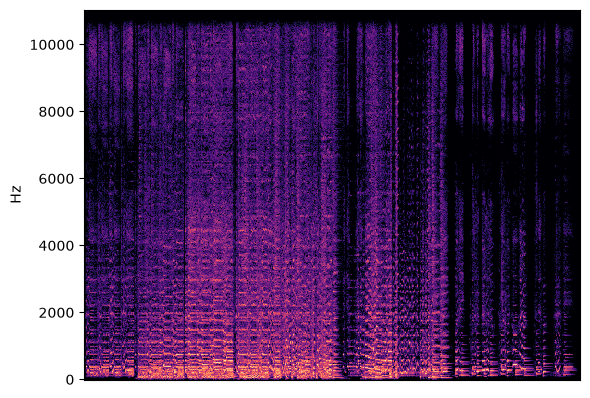

In [6]:
D = lb.amplitude_to_db(np.abs(lb.stft(y_harm)), ref=np.max)
lb.display.specshow(D, y_axis='hz')

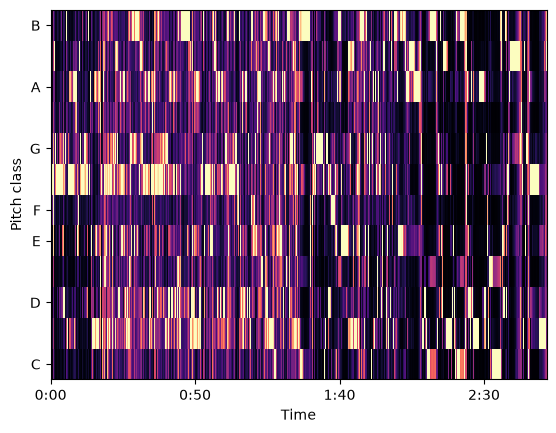

In [7]:
chromagram = lb.feature.chroma_cqt(y=y_harm, sr=sr)
lb.display.specshow(chromagram, y_axis='chroma', x_axis='time')

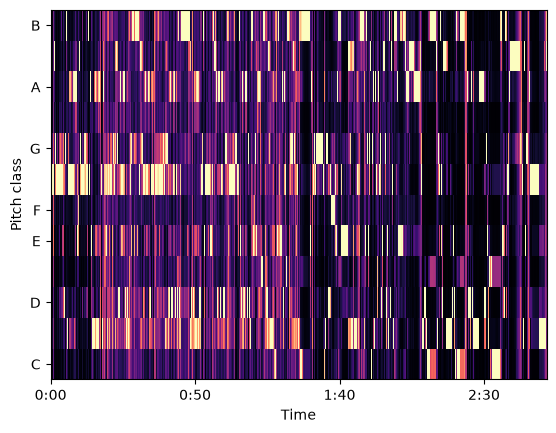

In [8]:
chroma_filter = np.minimum(chromagram,
                           lb.decompose.nn_filter(chromagram,
                                                       aggregate=np.median,
                                                       metric='cosine'))
lb.display.specshow(chroma_filter, y_axis='chroma', x_axis='time')

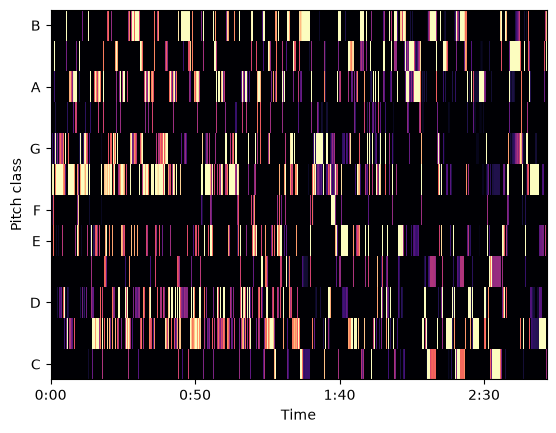

In [9]:
chroma_smooth = np.zeros_like(chroma_filter)
top3_idx = np.argpartition(chroma_filter, -3, axis=0)[-3:, :]
cols = np.arange(chroma_filter.shape[1])
chroma_smooth[top3_idx, cols] = chroma_filter[top3_idx, cols]
lb.display.specshow(chroma_smooth, y_axis='chroma', x_axis='time')

In [10]:
for i in range(0, len(labels), 4):
    print(', '.join(labels[i:i+4]))

C:maj, C#:maj, D:maj, D#:maj
E:maj, F:maj, F#:maj, G:maj
G#:maj, A:maj, A#:maj, B:maj
C:maj7, C#:maj7, D:maj7, D#:maj7
E:maj7, F:maj7, F#:maj7, G:maj7
G#:maj7, A:maj7, A#:maj7, B:maj7
C:min, C#:min, D:min, D#:min
E:min, F:min, F#:min, G:min
G#:min, A:min, A#:min, B:min
C:min7, C#:min7, D:min7, D#:min7
E:min7, F:min7, F#:min7, G:min7
G#:min7, A:min7, A#:min7, B:min7
C:normal7, C#:normal7, D:normal7, D#:normal7
E:normal7, F:normal7, F#:normal7, G:normal7
G#:normal7, A:normal7, A#:normal7, B:normal7
C:min9, C#:min9, D:min9, D#:min9
E:min9, F:min9, F#:min9, G:min9
G#:min9, A:min9, A#:min9, B:min9
C:dim, C#:dim, D:dim, D#:dim
E:dim, F:dim, F#:dim, G:dim
G#:dim, A:dim, A#:dim, B:dim
N


## Percussion

In [11]:
y_perc

array([1.7160213e-08, 4.7290891e-09, 1.3664436e-09, ..., 7.2535658e-15,
       1.4799959e-14, 9.5320760e-15], shape=(3785440,), dtype=float32)

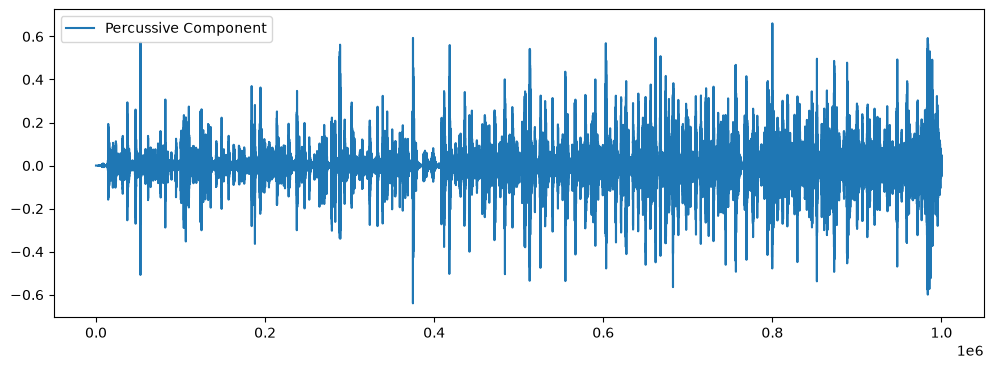

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(y_perc[0:1000000], label='Percussive Component')
plt.legend()
plt.show()

In [13]:
tempo, beats_static = lb.beat.beat_track(y=y, sr=sr, units='time', trim=False)

print(f"Tempo estimate: {tempo[0]:.2f} BPM")

Tempo estimate: 152.00 BPM
